In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

np.random.seed(42)

print("Setup complete ✓")

Setup complete ✓


In [2]:
def direction(player):
    """White moves toward increasing indices (+1), Black toward decreasing (-1)."""
    return 1 if player == "white" else -1

def bear_off_zone(player):
    """Home board indices: White = 18-23 (points 19-24), Black = 0-5 (points 1-6)."""
    return range(18, 24) if player == "white" else range(0, 6)

def sign(player):
    """White = positive checkers, Black = negative checkers."""
    return 1 if player == "white" else -1

def bar_entry_point(player, die):
    """
    Entry point from the bar.
    White enters the 1-6 zone (indices 0-5): die=1 -> index 0
    Black enters the 19-24 zone (indices 18-23): die=1 -> index 23
    """
    if player == "white":
        return die - 1
    return 24 - die

In [3]:
def legal_moves(board, die, player, bar_player):
    """
    Returns the list of legal moves (from, to) for ONE die value.
    from = -1 means "from the bar"
    to = -1 means "borne off (removed from the board)"
    """
    moves = []
    d = direction(player)
    s = sign(player)

    # ABSOLUTE PRIORITY: a checker on the bar must re-enter before anything else
    if bar_player > 0:
        entry = bar_entry_point(player, die)
        if board[entry] * s >= -1:
            moves.append((-1, entry))
        return moves

    # Check whether bearing off is allowed (all checkers in the home board)
    zone = bear_off_zone(player)
    checkers_outside_zone = 0
    for i in range(24):
        if i not in zone and board[i] * s > 0:
            checkers_outside_zone += abs(board[i])
    can_bear_off = (checkers_outside_zone == 0)

    for from_point in range(24):
        # Only move OWN checkers
        if board[from_point] * s <= 0:
            continue

        to_point = from_point + d * die

        # Case 1: the move exits the board -> potential bear-off
        if to_point < 0 or to_point > 23:
            if can_bear_off:
                # Check whether a checker further from the exit edge could use this die
                checker_further_back = False
                if player == "white":
                    for i in range(18, from_point):
                        if board[i] > 0:
                            checker_further_back = True
                else:
                    for i in range(from_point + 1, 6):
                        if board[i] < 0:
                            checker_further_back = True

                # Exact bear-off always allowed; overshoot only if no checker further back
                exact_distance = (23 - from_point + 1) if player == "white" else (from_point + 1)
                if die == exact_distance or (die > exact_distance and not checker_further_back):
                    moves.append((from_point, -1))
            continue

        # Case 2: normal move — landing point must hold at most 1 opposing checker
        if board[to_point] * s >= -1:
            moves.append((from_point, to_point))

    return moves

In [4]:
def legal_turn_sequences(board, dice, player, bar_player):
    """Generates all legal move sequences for a full turn (2 or 4 dice)."""
    s = sign(player)

    def explore(current_board, current_bar, remaining_dice):
        if not remaining_dice:
            return [[]]

        sequences = []
        die = remaining_dice[0]
        other_dice = remaining_dice[1:]
        possible_moves = legal_moves(current_board, die, player, current_bar)

        if not possible_moves:
            return explore(current_board, current_bar, other_dice)

        for (from_point, to_point) in possible_moves:
            nb = current_board.copy()
            new_bar = current_bar

            if from_point == -1:
                new_bar -= 1
            else:
                nb[from_point] -= s

            if to_point != -1:
                if nb[to_point] * s == -1:   # capturing a lone opposing checker
                    nb[to_point] = 0
                nb[to_point] += s

            continuations = explore(nb, new_bar, other_dice)
            for cont in continuations:
                sequences.append([(from_point, to_point, die)] + cont)

        return sequences

    all_sequences = explore(board, bar_player, dice)
    if not all_sequences:
        return []
    max_length = max(len(x) for x in all_sequences)
    return [x for x in all_sequences if len(x) == max_length]

In [5]:
class BackgammonEnv:
    def __init__(self, n_checkers=3):
        self.n_points = 24
        self.n_checkers = n_checkers
        self.reset()

    def reset(self):
        self.board = np.zeros(self.n_points)
        self.bar_white = 0
        self.bar_black = 0
        self.borne_off_white = 0
        self.borne_off_black = 0
        self.current_player = "white"

        self.board[0] = 1    # point 1
        self.board[1] = 1    # point 2
        self.board[2] = 1    # point 3

        self.board[23] = -1  # point 24
        self.board[22] = -1  # point 23
        self.board[21] = -1  # point 22

        return self._get_state()

    def _get_state(self):
        return {
            "board": self.board.copy(),
            "bar_white": self.bar_white,
            "bar_black": self.bar_black,
            "borne_off_white": self.borne_off_white,
            "borne_off_black": self.borne_off_black,
            "current_player": self.current_player
        }

    def player_bar(self, player):
        return self.bar_white if player == "white" else self.bar_black

    def available_moves(self, dice):
        return legal_turn_sequences(self.board, dice, self.current_player,
                                    self.player_bar(self.current_player))

    def play_move(self, from_point, to_point):
        p = self.current_player
        s = sign(p)

        if from_point == -1:
            if p == "white":
                self.bar_white -= 1
            else:
                self.bar_black -= 1
        else:
            self.board[from_point] -= s

        if to_point == -1:
            if p == "white":
                self.borne_off_white += 1
            else:
                self.borne_off_black += 1
            return

        if self.board[to_point] * s == -1:  # capture
            self.board[to_point] = 0
            if p == "white":
                self.bar_black += 1
            else:
                self.bar_white += 1

        self.board[to_point] += s

    def switch_player(self):
        self.current_player = "black" if self.current_player == "white" else "white"

    def game_over(self):
        if self.borne_off_white == self.n_checkers:
            return "white"
        if self.borne_off_black == self.n_checkers:
            return "black"
        return None

In [6]:
def check_invariant(env):
    n_white = np.sum(env.board[env.board > 0]) + env.bar_white + env.borne_off_white
    n_black = np.sum(np.abs(env.board[env.board < 0])) + env.bar_black + env.borne_off_black
    assert n_white == env.n_checkers, f"Error: {n_white} white checkers instead of {env.n_checkers}"
    assert n_black == env.n_checkers, f"Error: {n_black} black checkers instead of {env.n_checkers}"

In [7]:
def roll_dice():
    d1 = np.random.randint(1, 7)
    d2 = np.random.randint(1, 7)
    if d1 == d2:
        return [d1, d1, d1, d1]
    return [d1, d2]

In [8]:
def draw_board(env):
    board = env.board
    fig, ax = plt.subplots(figsize=(9, 5))

    outer_frame = patches.Rectangle((-0.7, -0.7), 15.4, 8.4, facecolor="none", edgecolor="black", linewidth=2)
    ax.add_patch(outer_frame)

    for coords in [(0, 4), (7, 4), (7, 0), (0, 0)]:
        rect = patches.Rectangle(coords, 6, 3, facecolor="none", edgecolor="black", linewidth=1)
        ax.add_patch(rect)

    ax.plot([6.5, 6.5], [-0.3, 7.3], color="black", linewidth=1.5)

    for i in range(24):
        if i <= 5:
            x = 12 - i; y_base = 0; direction_y = 1
        elif i <= 11:
            x = 11 - i; y_base = 0; direction_y = 1
        elif i <= 17:
            x = i - 12; y_base = 7; direction_y = -1
        else:
            x = i - 11; y_base = 7; direction_y = -1

        triangle = patches.Polygon(
            [(x, y_base), (x + 1, y_base), (x + 0.5, y_base + direction_y * 3)],
            closed=True, facecolor="none", edgecolor="black", linewidth=0.8
        )
        ax.add_patch(triangle)

        ax.text(x + 0.5, y_base + direction_y * 0.2, str(i + 1), fontsize=7, ha='center', color="gray")

        n = int(board[i])
        checker_color = "white" if n > 0 else "black"
        for c in range(abs(n)):
            y_checker = y_base + direction_y * (0.65 + c * 0.55)
            circle = patches.Circle((x + 0.5, y_checker), 0.22, facecolor=checker_color, edgecolor="black", linewidth=0.8)
            ax.add_patch(circle)

    ax.set_xlim(-1, 15)
    ax.set_ylim(-1.2, 8.2)
    ax.set_aspect('equal')
    ax.axis('off')
    title = (f"Turn: {env.current_player}  |  Bar W/B: {env.bar_white}/{env.bar_black}"
             f"  |  Borne off W/B: {env.borne_off_white}/{env.borne_off_black}")
    ax.set_title(title, fontsize=10)
    plt.tight_layout()
    return fig, ax


=== Turn 1 — white — dice: [4, 5] ===
Sequence played: [(2, 6, 4), (1, 6, 5)]


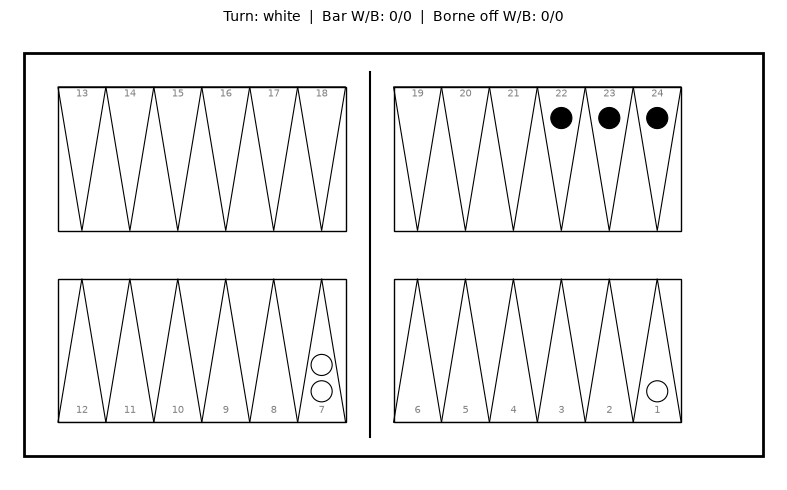


=== Turn 2 — black — dice: [5, 5, 5, 5] ===
Sequence played: [(22, 17, 5), (17, 12, 5), (21, 16, 5), (12, 7, 5)]


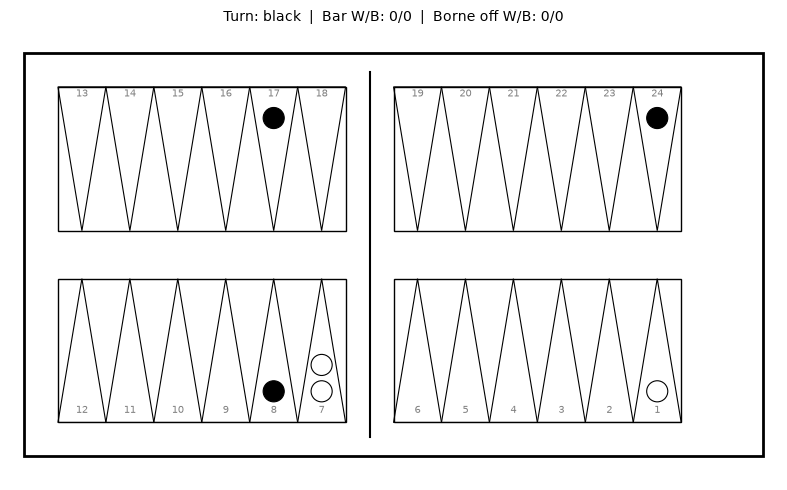


=== Turn 3 — white — dice: [3, 6] ===
Sequence played: [(6, 9, 3), (9, 15, 6)]


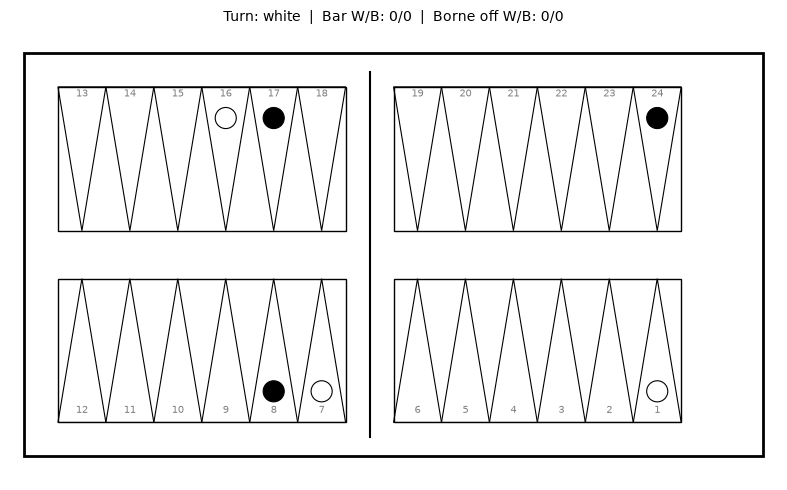


=== Turn 4 — black — dice: [2, 4] ===
Sequence played: [(16, 14, 2), (23, 19, 4)]


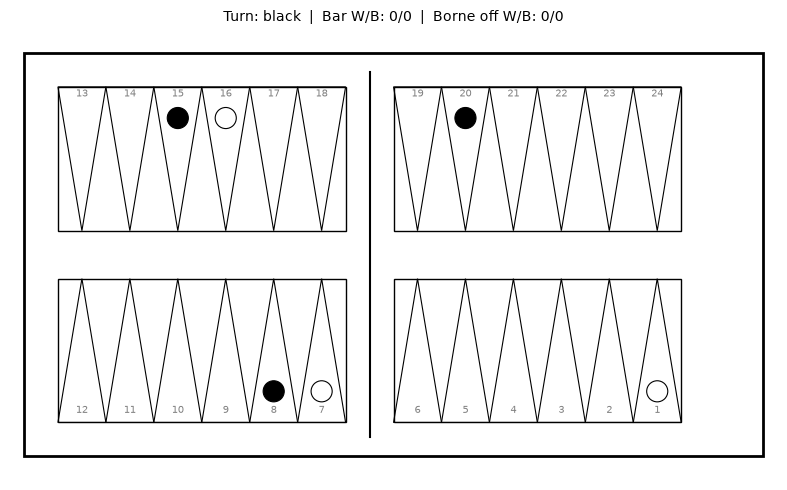


=== Turn 5 — white — dice: [2, 4] ===
Sequence played: [(6, 8, 2), (8, 12, 4)]


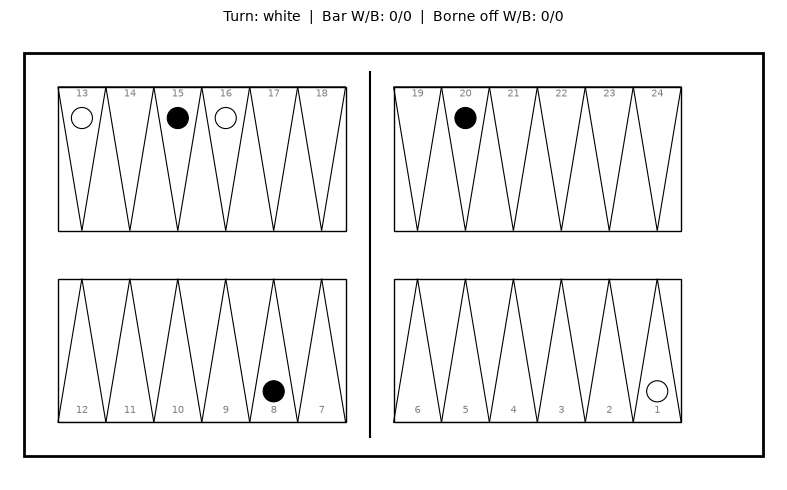


=== Turn 6 — black — dice: [1, 4] ===
Sequence played: [(14, 13, 1), (19, 15, 4)]


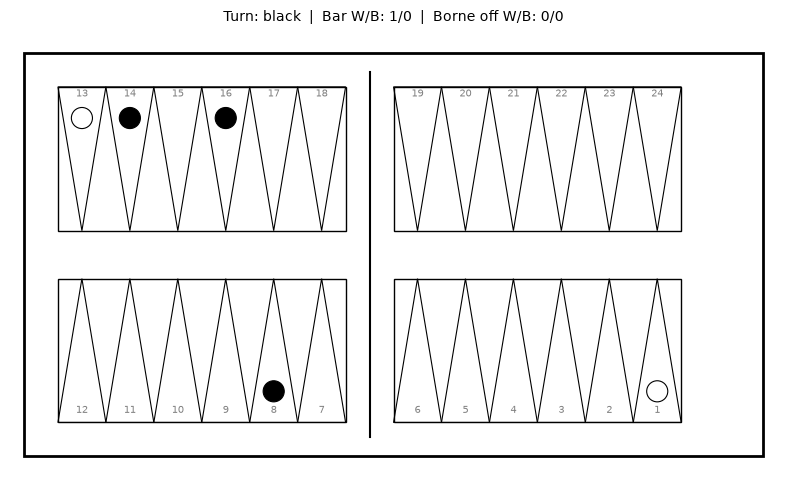


=== Turn 7 — white — dice: [5, 4] ===
Sequence played: [(-1, 4, 5), (0, 4, 4)]


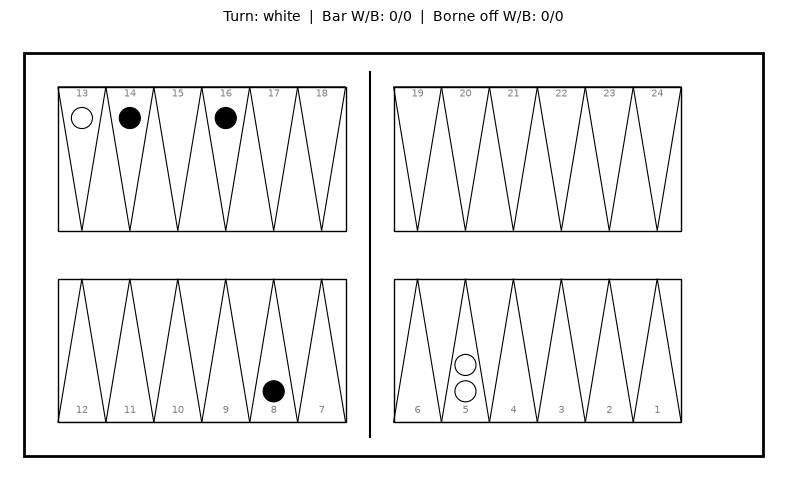


=== Turn 8 — black — dice: [1, 3] ===
Sequence played: [(7, 6, 1), (15, 12, 3)]


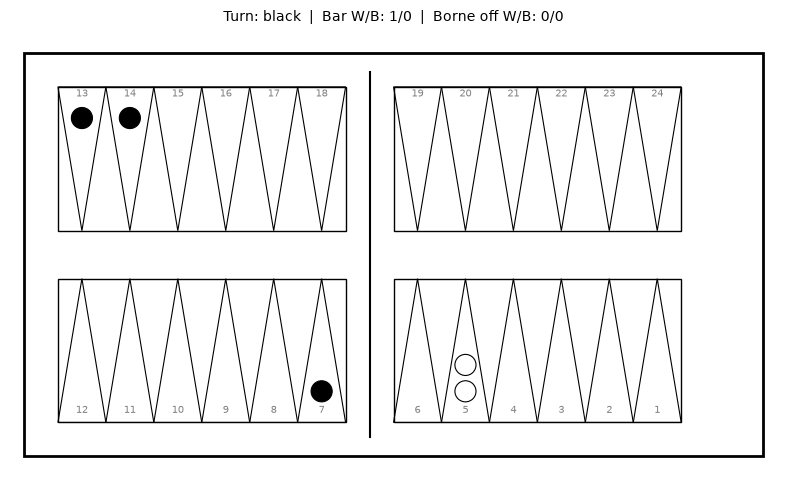


=== Turn 9 — white — dice: [2, 4] ===
Sequence played: [(-1, 1, 2), (4, 8, 4)]


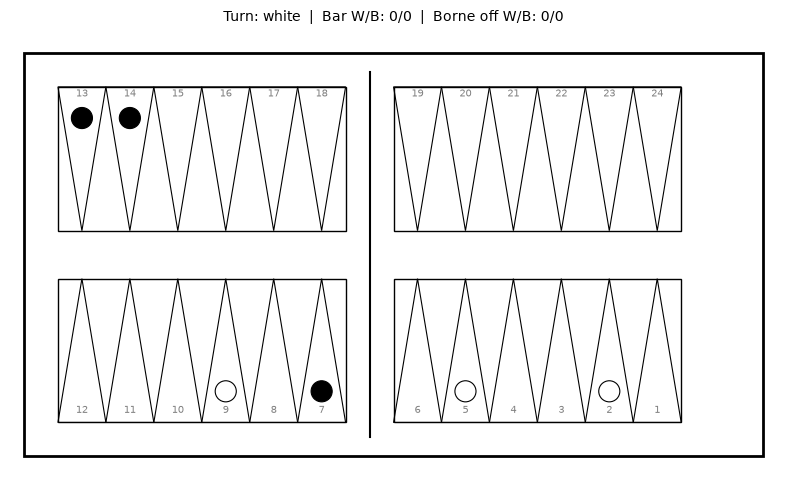


=== Turn 10 — black — dice: [6, 6, 6, 6] ===
Sequence played: [(13, 7, 6), (6, 0, 6), (12, 6, 6), (7, 1, 6)]


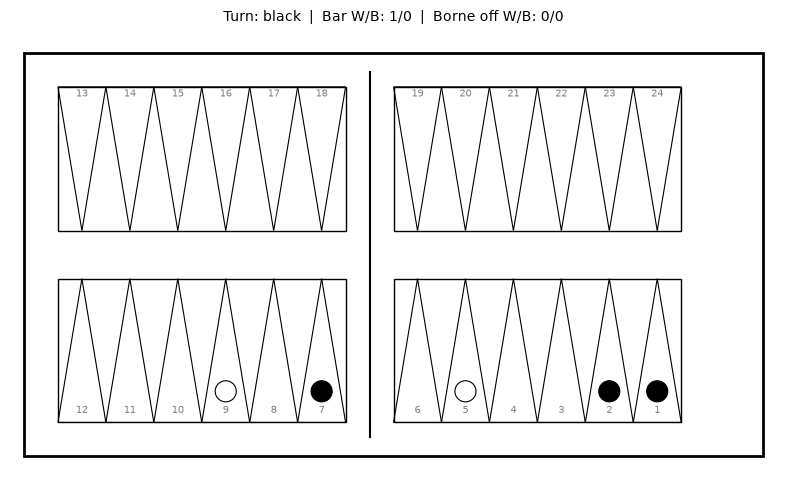


=== Turn 11 — white — dice: [6, 3] ===
Sequence played: [(-1, 5, 6), (8, 11, 3)]


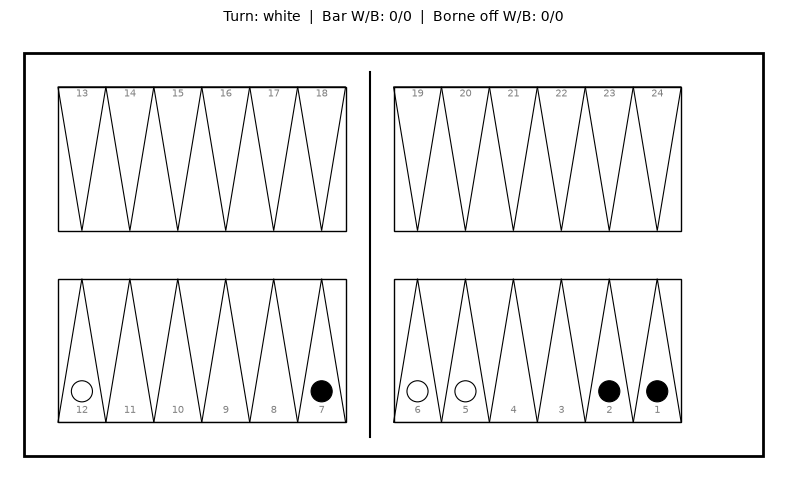


=== Turn 12 — black — dice: [4, 1] ===
Sequence played: [(6, 2, 4), (2, 1, 1)]


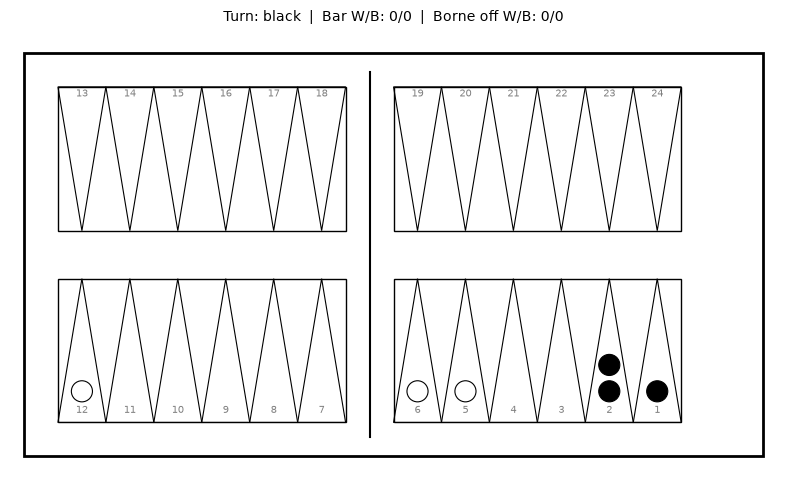


=== Turn 13 — white — dice: [5, 3] ===
Sequence played: [(11, 16, 5), (4, 7, 3)]


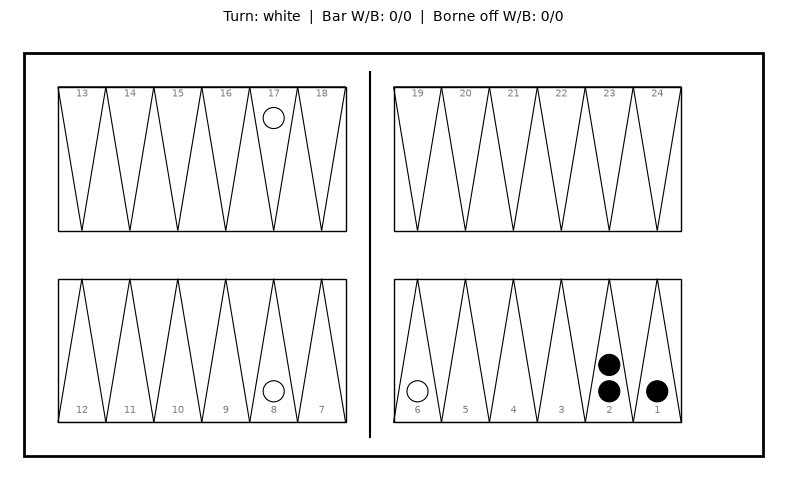


=== Turn 14 — black — dice: [5, 1] ===
Sequence played: [(1, -1, 5), (0, -1, 1)]


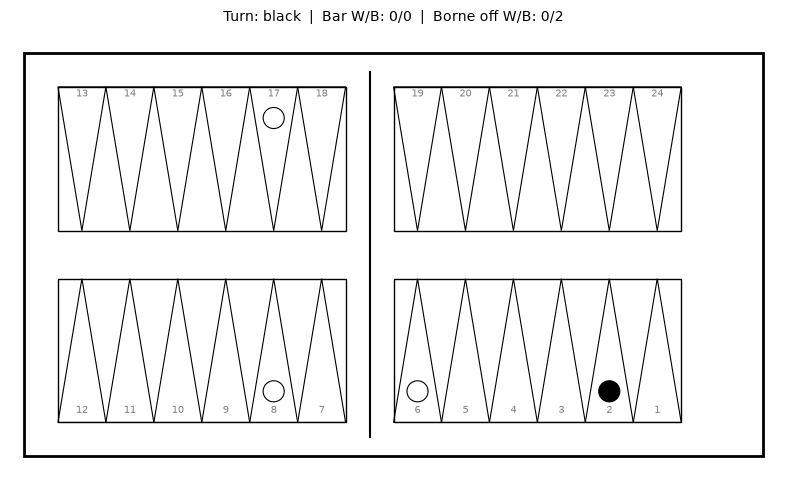


=== Turn 15 — white — dice: [2, 4] ===
Sequence played: [(5, 7, 2), (7, 11, 4)]


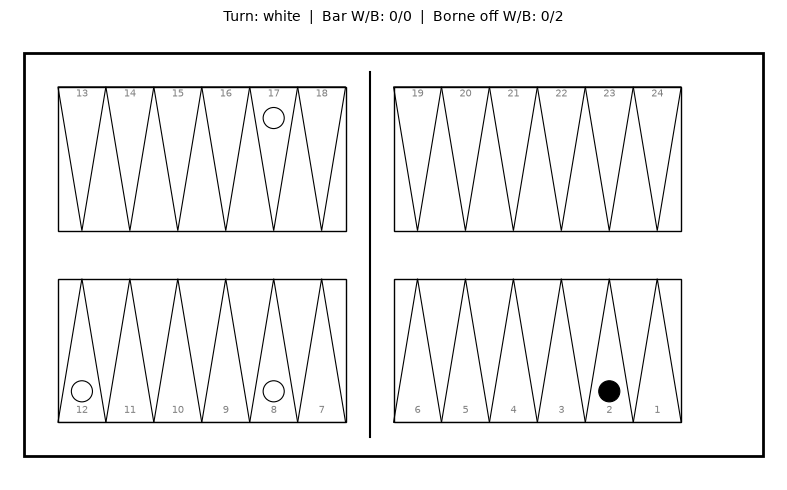


=== Turn 16 — black — dice: [4, 6] ===
Sequence played: [(1, -1, 4)]


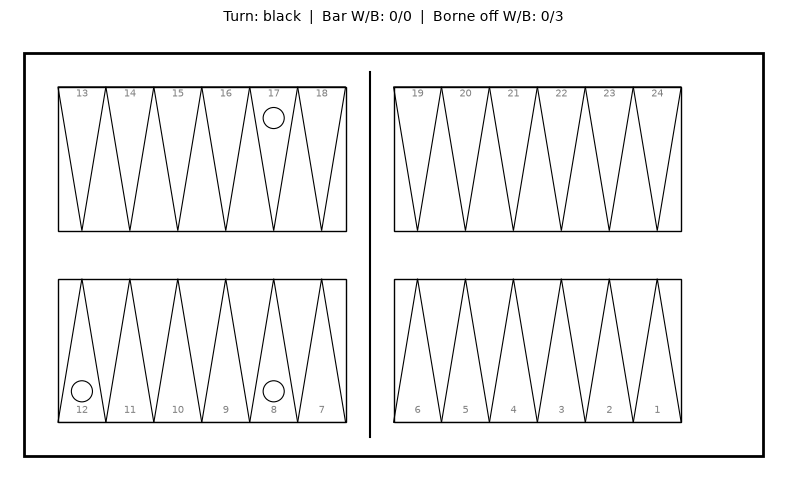


*** BLACK WON in 16 turns ***


In [9]:
def play_traced_game(n_turns=10):
    env = BackgammonEnv()
    env.reset()

    for turn in range(n_turns):
        dice = roll_dice()
        print(f"\n=== Turn {turn + 1} — {env.current_player} — dice: {dice} ===")

        sequences = env.available_moves(dice)

        if not sequences:
            print("No move available, passing.")
        else:
            seq = sequences[np.random.randint(len(sequences))]
            print("Sequence played:", seq)
            for (from_point, to_point, die) in seq:
                env.play_move(from_point, to_point)

        fig, ax = draw_board(env)
        plt.show()
        plt.close(fig)

        check_invariant(env)

        winner = env.game_over()
        if winner:
            print(f"\n*** {winner.upper()} WON in {turn + 1} turns ***")
            return env

        env.switch_player()

    return env

env_test = play_traced_game(n_turns=25)

In [10]:
def play_full_game(max_turns=500):
    env = BackgammonEnv()
    env.reset()

    for turn in range(max_turns):
        dice = roll_dice()
        sequences = env.available_moves(dice)

        if sequences:
            seq = sequences[np.random.randint(len(sequences))]
            for (from_point, to_point, die) in seq:
                env.play_move(from_point, to_point)

        check_invariant(env)

        winner = env.game_over()
        if winner:
            return turn + 1, winner

        env.switch_player()

    return max_turns, None

for i in range(5):
    n_turns, winner = play_full_game()
    print(f"Game {i+1}: {n_turns} turns — winner: {winner}")

Game 1: 16 turns — winner: black
Game 2: 24 turns — winner: black
Game 3: 15 turns — winner: white
Game 4: 23 turns — winner: white
Game 5: 15 turns — winner: white
